<a href="https://colab.research.google.com/github/DzhuJK/ML/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%9B%D0%B0%D1%8626_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук: лінійна регресія та регуляризація

**Курс:** Машинне навчання  
**Тема:** Linear Regression, Ridge, Lasso, Elastic Net

Цей ноутбук відповідає лекції про лінійну регресію та побудований як практичне продовження теоретичного матеріалу. У прикладах послідовно розглядаються проста й множинна лінійна регресія, метрики, залишки, недонавчання і перенавчання, L1/L2-регуляризація, Ridge, Lasso, Elastic Net, масштабування, крос-валідація, `GridSearchCV`, `Pipeline`, `ColumnTransformer` та навчальні криві.

У ноутбуці є два типи комірок:

- **Приклад** — готовий код, який потрібно виконати, проаналізувати та пояснити.
- **Самостійне завдання** — окрема кодова комірка з позначкою `TODO`. Її потрібно заповнити власноруч. Готового розв'язку в ноутбуці немає.

Рекомендація: виконувати комірки послідовно зверху вниз і після кожного блоку формулювати короткий висновок своїми словами.

## 0. Імпорт бібліотек і налаштування середовища

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Середовище готове до роботи.')

Середовище готове до роботи.


## 1. Проста лінійна регресія

Для однієї ознаки модель має вигляд

$$
\hat y = b_0 + b_1x.
$$

Тут $b_0$ — вільний член, а $b_1$ показує, на скільки одиниць у середньому змінюється прогноз $\hat y$ при збільшенні $x$ на одну одиницю.

Нижче згенеруємо дані, у яких істинна залежність приблизно дорівнює $y=5+2.4x$, але спостереження містять випадковий шум.

Вільний член b0: 4.907
Коефіцієнт b1: 2.451


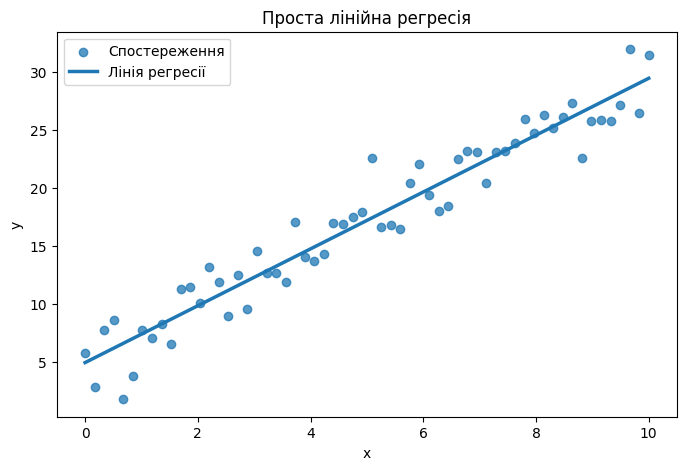

In [2]:
rng = np.random.default_rng(RANDOM_STATE)

X_simple = np.linspace(0, 10, 60).reshape(-1, 1)
y_simple = 5 + 2.4 * X_simple.ravel() + rng.normal(0, 2.5, size=len(X_simple))

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)
y_simple_pred = simple_model.predict(X_simple)

print(f'Вільний член b0: {simple_model.intercept_:.3f}')
print(f'Коефіцієнт b1: {simple_model.coef_[0]:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_simple.ravel(), y_simple, alpha=0.75, label='Спостереження')
plt.plot(X_simple.ravel(), y_simple_pred, linewidth=2.5, label='Лінія регресії')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Проста лінійна регресія')
plt.legend()
plt.show()

**Що потрібно побачити.** Коефіцієнт нахилу має бути близьким до 2.4, але не обов'язково дорівнювати йому точно, оскільки дані містять шум. `fit()` оцінює параметри за навчальними даними, а `predict()` лише обчислює прогноз для заданих значень ознак.

### Самостійне завдання 1

1. Створіть новий масив `X_new` зі значеннями 2, 5 і 8.
2. Отримайте прогнози моделі.
3. Виведіть таблицю з колонками `x` та `prediction`.
4. Одним реченням поясніть зміст отриманого коефіцієнта `b1`.

In [3]:
# TODO: Самостійне завдання 1
# Самостійне завдання 1
X_new = np.array([2, 5, 8]).reshape(-1, 1)

predictions = simple_model.predict(X_new)

result = pd.DataFrame({
"x": X_new.ravel(),
"prediction": predictions
})

print(result)

   x  prediction
0  2    9.809730
1  5   17.163214
2  8   24.516697


## 2. Метод найменших квадратів і ручний розрахунок коефіцієнтів

Для простої регресії коефіцієнт нахилу можна обчислити без готової моделі:

$$
b_1 = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2},
\qquad
b_0 = \bar y-b_1\bar x.
$$

Чисельник у формулі для $b_1$ відображає спільну зміну $x$ і $y$, а знаменник — варіативність самої ознаки $x$. Після знаходження нахилу вільний член підбирається так, щоб пряма проходила через точку $(\bar x, \bar y)$.

In [4]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3.0, 5.2, 6.8, 9.1, 10.9])

x_bar = x.mean()
y_bar = y.mean()

b1_manual = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0_manual = y_bar - b1_manual * x_bar

model_check = LinearRegression().fit(x.reshape(-1, 1), y)

print(f'Ручний розрахунок: b0={b0_manual:.4f}, b1={b1_manual:.4f}')
print(f'scikit-learn:     b0={model_check.intercept_:.4f}, b1={model_check.coef_[0]:.4f}')

Ручний розрахунок: b0=1.0900, b1=1.9700
scikit-learn:     b0=1.0900, b1=1.9700


### Самостійне завдання 2

Використайте масиви `x2 = [2, 4, 6, 8, 10]` та `y2 = [7, 11, 16, 19, 25]`. Власноруч обчисліть `b0` і `b1` за формулами, а потім перевірте результат за допомогою `LinearRegression`.

In [11]:
# TODO: Самостійне завдання 2
x = np.array([2, 4, 6, 8, 10], dtype=float)
y = np.array([7, 11, 16, 19, 25], dtype=float)

x_bar = x.mean()
y_bar = y.mean()

b1_manual = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0_manual = y_bar - b1_manual * x_bar

model = LinearRegression().fit(x.reshape(-1, 1), y)

print(f'Ручний розрахунок: b0={b0_manual:.4f}, b1={b1_manual:.4f}')
print(f'scikit-learn:     b0={model.intercept_:.4f}, b1={model.coef_[0]:.4f}')

Ручний розрахунок: b0=2.4000, b1=2.2000
scikit-learn:     b0=2.4000, b1=2.2000


## 3. Множинна лінійна регресія

У випадку кількох ознак модель має вигляд

$$
\hat y = b_0+b_1x_1+b_2x_2+\dots+b_px_p.
$$

Коефіцієнт $b_j$ інтерпретується як зміна прогнозу при збільшенні ознаки $x_j$ на одну одиницю **за інших рівних умов**, тобто при фіксованих значеннях інших ознак.

Для практики використаємо вбудований набір `diabetes`, тому ноутбук не потребує завантаження даних з Інтернету.

In [12]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()

print('Розмір X:', X.shape)
print('Розмір y:', y.shape)
display(X.head())

Розмір X: (442, 10)
Розмір y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [13]:
y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [14]:
multi_model = LinearRegression()
multi_model.fit(X, y)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': multi_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

display(coef_table)
print(f'Intercept: {multi_model.intercept_:.3f}')

,feature,coefficient
4,s1,-792.175639
8,s5,751.273700
2,bmi,519.845920
5,s2,476.739021
3,bp,324.384646
1,sex,-239.815644
7,s4,177.063238
6,s3,101.043268
9,s6,67.626692
0,age,-10.009866


Intercept: 152.133


Зверніть увагу: великий за модулем коефіцієнт не завжди означає, що ознака є «найважливішою». Порівняння коефіцієнтів залежить від масштабу ознак та їх взаємної кореляції.

## 4. Train/test та наївний baseline

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)



`DummyRegressor` не використовує закономірності в ознаках і в цьому прикладі прогнозує середнє значення цільової змінної з train. Якщо реальна модель не перевершує такий baseline, необхідно переглянути ознаки, постановку задачі або сам алгоритм.

## 5. Метрики якості регресії

У лекції розглядалися MAE, MSE, RMSE та $R^2$. Вони відповідають на різні питання.

- **MAE** показує середню абсолютну величину помилки.
- **MSE** сильніше штрафує великі помилки через піднесення залишку до квадрата.
- **RMSE** є коренем з MSE і вимірюється в тих самих одиницях, що й цільова змінна.
- **$R^2$** порівнює модель із прогнозом середнім значенням цільової змінної. На нових даних він може бути від'ємним.

In [16]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': (np.abs(y_true - y_pred) / y_true).mean() * 100
    }

metrics_baseline = regression_metrics(y_test, baseline_pred)
metrics_linear = regression_metrics(y_test, linear_pred)

pd.DataFrame([metrics_baseline, metrics_linear], index=['DummyRegressor', 'LinearRegression'])

,MAE,MSE,RMSE,R2,MAPE
DummyRegressor,64.006461,5361.533457,73.222493,-0.011963,62.791796
LinearRegression,42.794095,2900.193628,53.853446,0.452603,37.499826


### Самостійне завдання 3

Обчисліть MAE, RMSE і $R^2$ окремо, **не використовуючи** функцію `regression_metrics`. Порівняйте `DummyRegressor` і `LinearRegression`. У Markdown-комірці нижче поясніть, яка модель краща і чому не варто робити висновок лише за однією метрикою.

In [17]:
# TODO: Самостійне завдання 3
# Метрики для DummyRegressor
mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_baseline = r2_score(y_test, baseline_pred)

# Метрики для LinearRegression
mae_linear = mean_absolute_error(y_test, linear_pred)
rmse_linear = np.sqrt(mean_squared_error(y_test, linear_pred))
r2_linear = r2_score(y_test, linear_pred)
comparison = pd.DataFrame({
"MAE": [mae_baseline, mae_linear],
"RMSE": [rmse_baseline, rmse_linear],
"R²": [r2_baseline, r2_linear]
}, index=["DummyRegressor", "LinearRegression"])
comparison

,MAE,RMSE,R²
DummyRegressor,64.006461,73.222493,-0.011963
LinearRegression,42.794095,53.853446,0.452603


**Ваш висновок:**  
LinearRegression показала кращі результати за всіма метриками. Значення MAE та RMSE є меншими, що свідчить про нижчу середню помилку прогнозу. Також модель має R² = 0.452, тобто пояснює близько 45% варіації цільової змінної, тоді як DummyRegressor фактично не знаходить залежностей у даних.

Не варто робити висновок лише за однією метрикою, оскільки кожна з них оцінює якість моделі з різних сторін. Наприклад, MAE показує середню абсолютну помилку, RMSE сильніше штрафує великі помилки, а R² характеризує частку поясненої варіації даних.

## 6. Залишки та діагностика моделі

Залишок для об'єкта визначається як

$$
e_i = y_i-\hat y_i.
$$

Якщо модель добре описує систематичну частину залежності, на графіку `prediction → residual` не повинно бути вираженої структури. Дуга може вказувати на нелінійність, а «воронка» — на зміну дисперсії помилки.

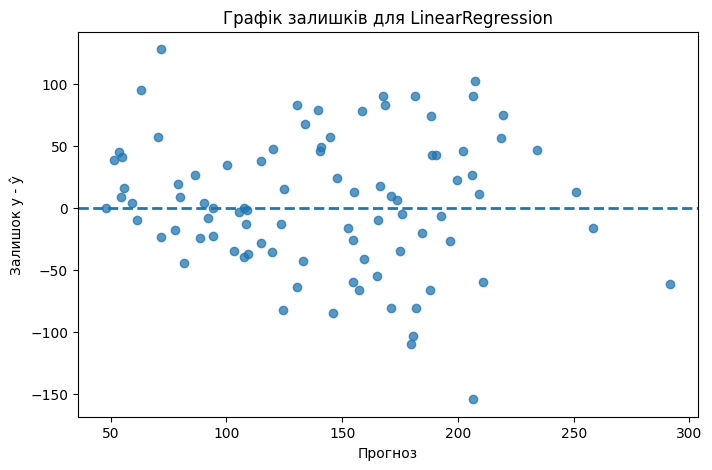

In [18]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel('Прогноз')
plt.ylabel('Залишок y - ŷ')
plt.title('Графік залишків для LinearRegression')
plt.show()

## 7. Недонавчання і перенавчання на поліноміальній регресії

Лінійна модель може недонавчатися, якщо реальна залежність нелінійна. Один зі способів збільшити гнучкість — створити поліноміальні ознаки. Але занадто високий ступінь полінома збільшує ризик перенавчання.

Порівняємо ступені 1, 4 і 15 на невеликій синтетичній вибірці.

In [19]:
rng = np.random.default_rng(RANDOM_STATE)
X_poly = np.sort(rng.uniform(-3, 3, 45)).reshape(-1, 1)
y_true_poly = np.sin(X_poly.ravel()) + 0.25 * X_poly.ravel()
y_poly = y_true_poly + rng.normal(0, 0.22, size=len(X_poly))

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=RANDOM_STATE
)

def fit_polynomial(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression()),
    ])
    model.fit(X_p_train, y_p_train)
    train_pred = model.predict(X_p_train)
    test_pred = model.predict(X_p_test)
    return model, {
        'degree': degree,
        'train_rmse': root_mean_squared_error(y_p_train, train_pred),
        'test_rmse': root_mean_squared_error(y_p_test, test_pred),
    }

results = []
models_poly = {}
for degree in [1, 4, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

pd.DataFrame(results)

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,4,0.144969,0.203183
2,15,0.091024,0.244266


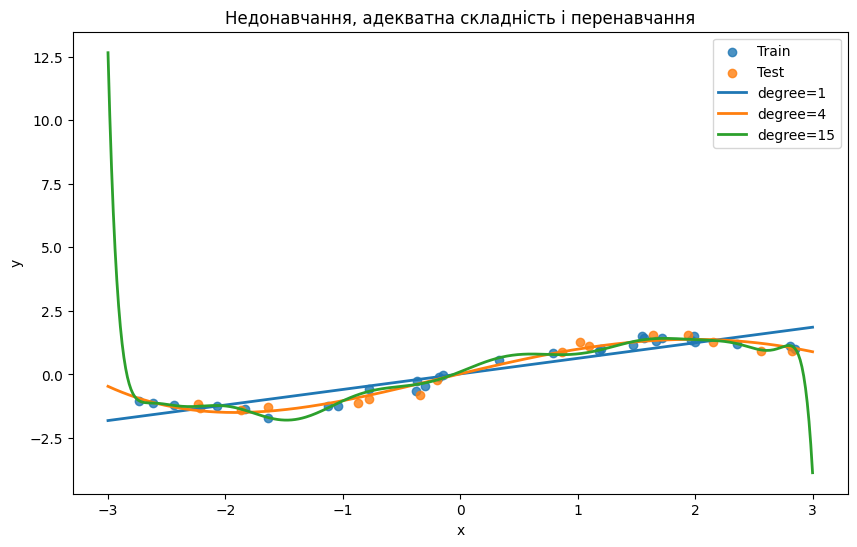

In [20]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_p_train, y_p_train, label='Train', alpha=0.8)
plt.scatter(X_p_test, y_p_test, label='Test', alpha=0.8)

for degree in [1, 4, 15]:
    plt.plot(grid, models_poly[degree].predict(grid), linewidth=2, label=f'degree={degree}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Недонавчання, адекватна складність і перенавчання')
plt.legend()
plt.show()

### Самостійне завдання 4

1. Додайте до порівняння ступені 2, 6 і 10.
2. Побудуйте таблицю `degree`, `train_rmse`, `test_rmse`.
3. Визначте ступінь із найменшим `test_rmse`.
4. Поясніть, чому мінімальна train-помилка не гарантує найкращої моделі.

In [22]:
# TODO: Самостійне завдання 4
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
X_poly = np.sort(rng.uniform(-3, 3, 45)).reshape(-1, 1)
y_true_poly = np.sin(X_poly.ravel()) + 0.25 * X_poly.ravel()
y_poly = y_true_poly + rng.normal(0, 0.22, size=len(X_poly))

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=RANDOM_STATE
)

def fit_polynomial(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression()),
    ])
    model.fit(X_p_train, y_p_train)
    train_pred = model.predict(X_p_train)
    test_pred = model.predict(X_p_test)
    return model, {
        'degree': degree,
        'train_rmse': root_mean_squared_error(y_p_train, train_pred),
        'test_rmse': root_mean_squared_error(y_p_test, test_pred),
    }

# ---- Розширений список ступенів ----
results = []
models_poly = {}
for degree in [1, 2, 4, 6, 10, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

df = pd.DataFrame(results)
print(df.to_string(index=False))

best_degree = df.loc[df['test_rmse'].idxmin(), 'degree']
print(f'\nНайкращий ступінь за test_rmse: {int(best_degree)}')

 degree  train_rmse  test_rmse
      1    0.392868   0.465437
      2    0.392821   0.463992
      4    0.144969   0.203183
      6    0.137065   0.196267
     10    0.129074   0.191782
     15    0.091024   0.244266

Найкращий ступінь за test_rmse: 10


## 8. Регуляризація: загальна ідея

Коли модель має багато ознак або ознаки сильно корельовані, коефіцієнти можуть ставати нестабільними. Регуляризація додає до функції втрат штраф за великі коефіцієнти.

Для Ridge використовується L2-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p} b_j^2,
$$

для Lasso — L1-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p}|b_j|.
$$

Параметр $\alpha$ керує силою регуляризації. Якщо $\alpha=0$, штраф зникає. Надто велике $\alpha$ може надмірно стиснути коефіцієнти й спричинити недонавчання.

## 9. Чому перед Ridge, Lasso та Elastic Net потрібне масштабування

In [23]:
# Штучно змінюємо масштаби кількох ознак, щоб побачити роль StandardScaler.
X_scaled_demo = X.copy()
X_scaled_demo['bmi'] = X_scaled_demo['bmi'] * 1000
X_scaled_demo['bp'] = X_scaled_demo['bp'] * 0.01

Xsd_train, Xsd_test, ysd_train, ysd_test = train_test_split(
    X_scaled_demo, y, test_size=0.2, random_state=RANDOM_STATE
)

ridge_no_scaling = Ridge(alpha=10.0).fit(Xsd_train, ysd_train)
ridge_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(Xsd_train, ysd_train)

print('Ridge без масштабування RMSE:', root_mean_squared_error(ysd_test, ridge_no_scaling.predict(Xsd_test)))
print('Ridge + StandardScaler RMSE:', root_mean_squared_error(ysd_test, ridge_pipeline.predict(Xsd_test)))

Ridge без масштабування RMSE: 62.25349241861679
Ridge + StandardScaler RMSE: 53.626287568895194


Штраф застосовується безпосередньо до коефіцієнтів. Якщо ознаки вимірюються в дуже різних масштабах, одна й та сама величина коефіцієнта не має однакового змісту. Тому `StandardScaler` зазвичай включають у `Pipeline` перед регуляризованою лінійною моделлю.

## 10. Ridge-регресія: L2-регуляризація

In [24]:
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print(regression_metrics(y_test, ridge_pred))

{'MAE': 42.81199941834889, 'MSE': 2892.0145657501726, 'RMSE': 53.777454065343896, 'R2': 0.45414652070698225, 'MAPE': np.float64(37.44816405198748)}


## 11. Lasso: L1-регуляризація

In [25]:
lasso = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(alpha=1.0, max_iter=20000)),
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

lasso_coef = lasso.named_steps['reg'].coef_
print(regression_metrics(y_test, lasso_pred))
print('Кількість нульових коефіцієнтів:', np.sum(np.isclose(lasso_coef, 0)))

{'MAE': 42.80298373195777, 'MSE': 2824.568094049959, 'RMSE': 53.14666587896139, 'R2': 0.46687670944102466, 'MAPE': np.float64(37.43982076869067)}
Кількість нульових коефіцієнтів: 1


На відміну від Ridge, Lasso може занулювати частину коефіцієнтів. Саме тому L1-регуляризацію іноді використовують як вбудований механізм відбору ознак. Проте при сильно корельованих предикторах вибір конкретної ознаки може бути нестабільним.

## 12. Elastic Net: поєднання L1 та L2

In [26]:
elastic = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
])

elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

print(regression_metrics(y_test, elastic_pred))

{'MAE': 42.873332243316874, 'MSE': 2866.4612552977674, 'RMSE': 53.539343060013046, 'R2': 0.4589695819678379, 'MAPE': np.float64(37.40678706534485)}


В Elastic Net параметр `alpha` визначає загальну силу регуляризації, а `l1_ratio` — співвідношення між L1 та L2. Значення `l1_ratio=1` наближає модель до Lasso, а `l1_ratio=0` — до Ridge.

### Самостійне завдання 5

Навчіть на одному й тому самому train/test розбитті чотири моделі: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`. Для регуляризованих моделей використайте `StandardScaler` у `Pipeline`. Побудуйте таблицю з MAE, RMSE та $R^2$.

In [27]:
# TODO: Самостійне завдання 5
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
    }

# Лінійна регресія — масштабування не потрібне, але для єдиного стилю можна без нього
lin = Pipeline([('reg', LinearRegression())])

# Регуляризовані моделі — обов'язково зі StandardScaler
ridge = Pipeline([('scale', StandardScaler()),
                  ('reg', Ridge(alpha=1.0))])

lasso = Pipeline([('scale', StandardScaler()),
                  ('reg', Lasso(alpha=0.1, max_iter=20000))])

elastic = Pipeline([('scale', StandardScaler()),
                    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000))])

models = {
    'LinearRegression': lin,
    'Ridge':            ridge,
    'Lasso':            lasso,
    'ElasticNet':       elastic,
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    m = regression_metrics(y_test, pred)
    rows.append({'model': name, **m})

df = pd.DataFrame(rows).round(4)
print(df.to_string(index=False))

           model     MAE       MSE    RMSE     R2
LinearRegression 42.7941 2900.1936 53.8534 0.4526
           Ridge 42.8120 2892.0146 53.7775 0.4541
           Lasso 42.8052 2884.6243 53.7087 0.4555
      ElasticNet 42.8733 2866.4613 53.5393 0.4590


## 13. Крос-валідація

Одне train/test розбиття залежить від випадкового поділу. K-fold cross-validation кілька разів змінює validation-частину і дає більш стійку оцінку якості моделі. Важливо, що preprocessing повинен бути всередині `Pipeline`, щоб на кожному фолді параметри масштабування оцінювалися лише з train-частини.

In [28]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_cv_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

scores = cross_validate(
    ridge_cv_model,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    return_train_score=True,
)

cv_table = pd.DataFrame({
    'fold': np.arange(1, 6),
    'train_R2': scores['train_r2'],
    'val_R2': scores['test_r2'],
    'val_MAE': -scores['test_mae'],
    'val_RMSE': -scores['test_rmse'],
})

display(cv_table)
print('Середній validation RMSE:', cv_table['val_RMSE'].mean())

,fold,train_R2,val_R2,val_MAE,val_RMSE
0,1,0.527632,0.454147,42.811999,53.777454
1,2,0.497124,0.571674,41.616638,51.692906
2,3,0.538901,0.391921,47.224871,57.530264
3,4,0.494045,0.583169,42.166318,52.966248
4,5,0.540152,0.394449,47.397540,58.168400


Середній validation RMSE: 54.827054212084306


## 14. Підбір alpha для Ridge за GridSearchCV

In [29]:
ridge_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge()),
])

param_grid_ridge = {
    'reg__alpha': np.logspace(0, 5, 13)
}

ridge_search = GridSearchCV(
    ridge_search_model,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

print('Найкраще alpha:', ridge_search.best_params_['reg__alpha'])
print('CV RMSE:', -ridge_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Найкраще alpha: 1.0
CV RMSE: 55.374175368673455
Test RMSE: 53.777454065343896


Тестову вибірку не використовують для підбору `alpha`. Гіперпараметр обирається всередині train за крос-валідацією, а test використовується лише після завершення вибору моделі.

## 15. Підбір alpha і l1_ratio для Elastic Net

In [30]:
elastic_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid_elastic = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

elastic_search = GridSearchCV(
    elastic_search_model,
    param_grid=param_grid_elastic,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

elastic_search.fit(X_train, y_train)

print('Найкращі параметри:', elastic_search.best_params_)
print('CV RMSE:', -elastic_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, elastic_search.predict(X_test)))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test RMSE: 53.74450007977087


### Самостійне завдання 6

Виконайте `GridSearchCV` для Lasso. Перевірте не менше 10 значень `alpha` у логарифмічній шкалі. Порівняйте найкращий Lasso з найкращим Ridge за однаковою схемою CV.

In [31]:
# TODO: Самостійне завдання 6
# 1. Pipeline
lasso_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(max_iter=50000)),
])

# 2. Сітка alpha на логарифмічній шкалі — 13 значень
param_grid_lasso = {
    'reg__alpha': np.logspace(-4, 2, 13)   # 0.0001 … 100
}

# 3. GridSearchCV
lasso_search = GridSearchCV(
    lasso_search_model,
    param_grid_lasso,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
lasso_search.fit(X_train, y_train)

# 4. Порівняння
print('Lasso — найкраща alpha:', lasso_search.best_params_['reg__alpha'])
print('Lasso — CV RMSE :', -lasso_search.best_score_)
print('Lasso — Test RMSE:', root_mean_squared_error(y_test, lasso_search.predict(X_test)))

print()
print('Ridge — найкраща alpha:', ridge_search.best_params_['reg__alpha'])
print('Ridge — CV RMSE :', -ridge_search.best_score_)
print('Ridge — Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Lasso — найкраща alpha: 0.1
Lasso — CV RMSE : 55.353957634803294
Lasso — Test RMSE: 53.70869844573793

Ridge — найкраща alpha: 1.0
Ridge — CV RMSE : 55.374175368673455
Ridge — Test RMSE: 53.777454065343896


## 16. Як регуляризація змінює коефіцієнти

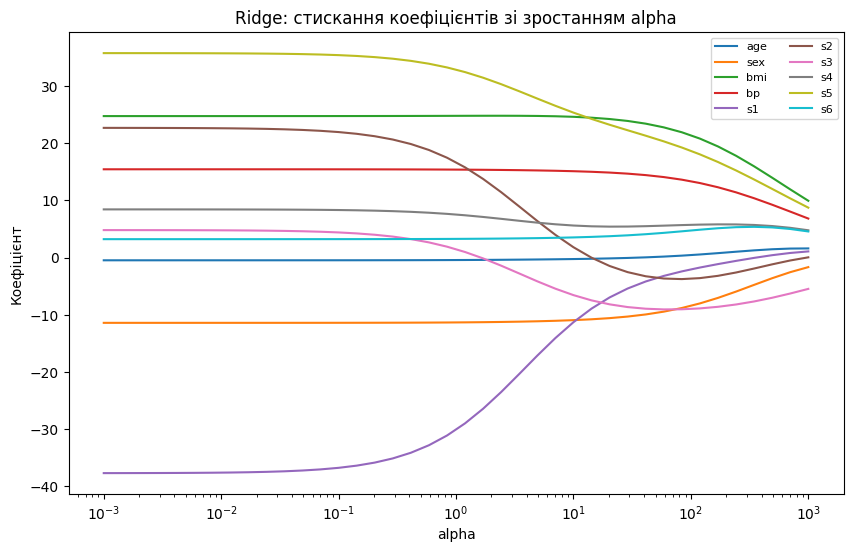

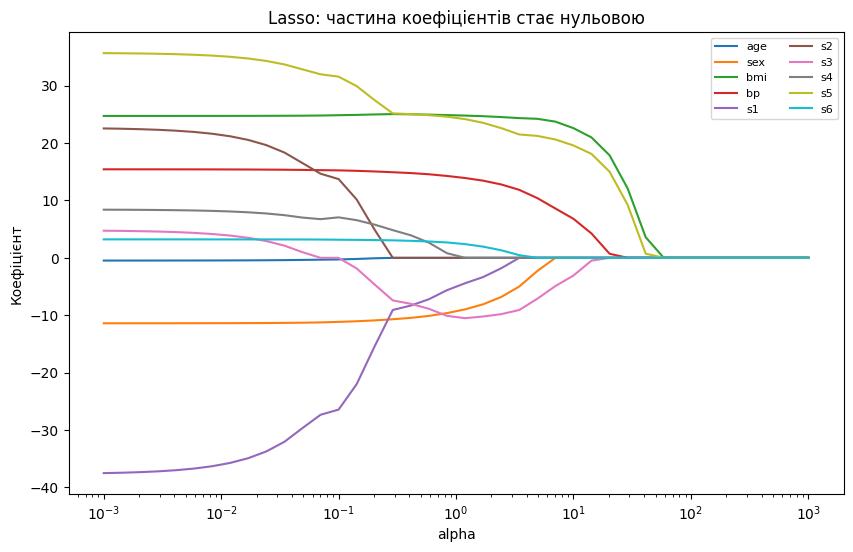

In [32]:
alphas = np.logspace(-3, 3, 40)
ridge_paths = []
lasso_paths = []

X_for_path = StandardScaler().fit_transform(X)

for alpha in alphas:
    ridge_m = Ridge(alpha=alpha).fit(X_for_path, y)
    lasso_m = Lasso(alpha=alpha, max_iter=30000).fit(X_for_path, y)
    ridge_paths.append(ridge_m.coef_)
    lasso_paths.append(lasso_m.coef_)

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, ridge_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Ridge: стискання коефіцієнтів зі зростанням alpha')
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, lasso_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Lasso: частина коефіцієнтів стає нульовою')
plt.legend(ncol=2, fontsize=8)
plt.show()

Ці графіки демонструють ключову різницю. Ridge плавно стискає коефіцієнти до нуля, тоді як Lasso може зробити частину з них точно нульовими.

## 17. Мультиколінеарність і стабільність коефіцієнтів

In [33]:
rng = np.random.default_rng(RANDOM_STATE)
n = 250
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=0.03, size=n)  # дуже сильна кореляція
x3 = rng.normal(size=n)
y_corr = 5 * x1 + 5 * x2 + 0.5 * x3 + rng.normal(scale=1.5, size=n)

X_corr = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
print(X_corr.corr())

ols_corr = LinearRegression().fit(X_corr, y_corr)
ridge_corr = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(X_corr, y_corr)

coef_compare = pd.DataFrame({
    'feature': X_corr.columns,
    'OLS': ols_corr.coef_,
    'Ridge_scaled': ridge_corr.named_steps['reg'].coef_,
})
coef_compare

          x1        x2        x3
x1  1.000000  0.999515 -0.008921
x2  0.999515  1.000000 -0.010420
x3 -0.008921 -0.010420  1.000000


,feature,OLS,Ridge_scaled
0,x1,5.446248,4.546617
1,x2,4.410887,4.534370
2,x3,0.444792,0.439193


За наявності дуже корельованих ознак окремі коефіцієнти OLS можуть бути нестабільними: невеликі зміни даних здатні суттєво змінити їх значення. Ridge зменшує variance коефіцієнтів завдяки L2-штрафу.

## 18. Категоріальні ознаки, пропуски та ColumnTransformer

У реальній табличній задачі дані часто містять числові й категоріальні ознаки, а також пропуски. Їх потрібно обробляти всередині `Pipeline`, щоб не створювати витік інформації.

In [34]:
rng = np.random.default_rng(RANDOM_STATE)
n = 300

housing = pd.DataFrame({
    'area': rng.normal(75, 20, n).clip(25, 150),
    'rooms': rng.integers(1, 6, n),
    'age': rng.integers(0, 70, n).astype(float),
    'district': rng.choice(['center', 'north', 'south'], n, p=[0.3, 0.35, 0.35]),
})

# Додаємо кілька пропусків.
housing.loc[rng.choice(n, 18, replace=False), 'age'] = np.nan

price = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    + rng.normal(0, 12000, n)
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ['area', 'rooms', 'age']
categorical_features = ['district']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

housing_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0)),
])

housing_model.fit(X_h_train, y_h_train)
housing_pred = housing_model.predict(X_h_test)

print('Housing RMSE:', root_mean_squared_error(y_h_test, housing_pred))
print('Housing R2:', r2_score(y_h_test, housing_pred))
print('Housing MAE:', mean_absolute_error(y_h_test, housing_pred))
print('MAPE', mean_absolute_percentage_error(y_h_test, housing_pred))

Housing RMSE: 10925.278371503928
Housing R2: 0.9068908686435069
Housing MAE: 8737.023097309464
MAPE 0.07276440135248957


In [35]:
housing

,area,rooms,age,district
0,81.094342,4,17.0,south
1,54.200318,2,66.0,south
2,90.009024,2,37.0,center
3,93.811294,2,21.0,south
4,35.979296,3,29.0,south
...,...,...,...,...
295,78.530248,4,30.0,center
296,80.919880,5,45.0,center
297,67.561708,3,38.0,center
298,39.865564,3,67.0,south


In [36]:
price

,0
0,146888.018855
1,43872.771974
2,175189.836338
3,145447.579696
4,58699.634461
...,...
295,179796.834387
296,197085.341513
297,166868.377770
298,32562.347956


### Самостійне завдання 7

Додайте до таблиці `housing` нову категоріальну ознаку `condition` зі значеннями `new`, `good`, `needs_repair`. Включіть її в `ColumnTransformer`, перенавчіть модель і перевірте, чи змінилася test-помилка.

In [37]:
# TODO: Самостійне завдання 7
rng = np.random.default_rng(RANDOM_STATE)
n = 300

housing = pd.DataFrame({
    'area': rng.normal(75, 20, n).clip(25, 150),
    'rooms': rng.integers(1, 6, n),
    'age': rng.integers(0, 70, n).astype(float),
    'district': rng.choice(['center', 'north', 'south'], n, p=[0.3, 0.35, 0.35]),
})

# Додаємо пропуски в age
housing.loc[rng.choice(n, 18, replace=False), 'age'] = np.nan

# --- НОВА КАТЕГОРІАЛЬНА ОЗНАКА ---
housing['condition'] = rng.choice(
    ['new', 'good', 'needs_repair'], n, p=[0.3, 0.5, 0.2]
)

price = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    # додаємо вплив condition у цільову змінну
    + housing['condition'].map({'new': 30000, 'good': 10000, 'needs_repair': 0})
    + rng.normal(0, 12000, n)
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ['area', 'rooms', 'age']
categorical_features = ['district', 'condition']   # ← додали condition

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

housing_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0)),
])

housing_model.fit(X_h_train, y_h_train)
housing_pred = housing_model.predict(X_h_test)

print('Housing RMSE:', root_mean_squared_error(y_h_test, housing_pred))
print('Housing R2  :', r2_score(y_h_test, housing_pred))
print('Housing MAE :', mean_absolute_error(y_h_test, housing_pred))
print('MAPE        :', mean_absolute_percentage_error(y_h_test, housing_pred))

Housing RMSE: 11715.74327487308
Housing R2  : 0.9039976694258479
Housing MAE : 9655.091533090199
MAPE        : 0.07475152468472367


## 19. Навчальні криві

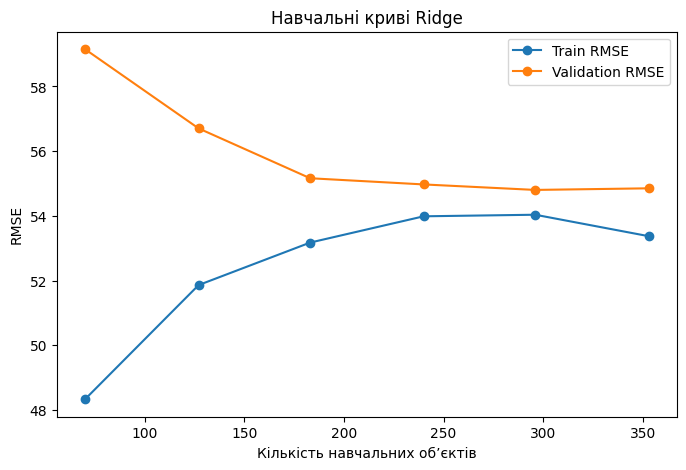

In [38]:
learning_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=ridge_search.best_params_['reg__alpha'])),
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1,
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse_curve, marker='o', label='Validation RMSE')
plt.xlabel('Кількість навчальних об’єктів')
plt.ylabel('RMSE')
plt.title('Навчальні криві Ridge')
plt.legend()
plt.show()

Якщо train і validation помилки високі та близькі, це ознака можливого недонавчання. Якщо train-помилка значно нижча за validation, це може свідчити про високу variance та перенавчання. Навчальні криві допомагають зрозуміти, чи може збільшення обсягу даних бути корисним.

## 20. Повний приклад: коректний вибір моделі без використання test

In [39]:
# 1. Test відкладаємо один раз.
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 2. Вибір моделі відбувається тільки всередині train за CV.
model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.5, 0.9],
}

search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_final_train, y_final_train)

# 3. Лише після завершення підбору оцінюємо test.
final_pred = search.predict(X_final_test)

print('Найкращі параметри:', search.best_params_)
print('CV RMSE:', -search.best_score_)
print('Test metrics:', regression_metrics(y_final_test, final_pred))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test metrics: {'MAE': 42.81393247843441, 'MSE': 2888.4712888244917, 'RMSE': np.float64(53.74450007977087), 'R2': 0.4548152967432053}


# 21. Підсумкове практичне завдання для самостійної роботи

Виконайте повний експеримент на наборі `diabetes`. Цей блок потрібно зробити **самостійно**, використовуючи попередні приклади лише як орієнтир.

Вимоги до роботи:

1. Завантажити `load_diabetes(as_frame=True)` і переглянути структуру даних.
2. Відкласти 20% даних у test із `random_state=42`.
3. Побудувати `DummyRegressor` і `LinearRegression` як baseline.
4. Обчислити MAE, RMSE та $R^2$ на test.
5. Побудувати Ridge, Lasso та Elastic Net через `Pipeline` із `StandardScaler`.
6. Виконати 5-fold cross-validation.
7. Для Ridge і Lasso підібрати `alpha`; для Elastic Net — `alpha` та `l1_ratio`.
8. Порівняти моделі в одній таблиці.
9. Для найкращої моделі побудувати графік `фактичні значення → прогноз` та графік залишків.
10. Проаналізувати коефіцієнти найкращої лінійної моделі.
11. Сформулювати підсумковий висновок: яка модель обрана, за якою метрикою та чому.

Нижче залишені окремі комірки для кожного етапу.

### Крок 1. Дані

In [40]:
# TODO: Завантажте diabetes, сформуйте X_task та y_task, виведіть shape і перші рядки.
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

X_task = df.drop(columns='target')
y_task = df['target']

print('X shape:', X_task.shape)
print('y shape:', y_task.shape)
print(X_task.head())

X shape: (442, 10)
y shape: (442,)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


### Крок 2. Train/test

In [41]:
# TODO: Виконайте train_test_split з test_size=0.2 та random_state=42.
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_task, y_task, test_size=0.2, random_state=42
)
print(X_tr.shape, X_te.shape)

(353, 10) (89, 10)


### Крок 3. Baseline

In [43]:
# TODO: Навчіть DummyRegressor та LinearRegression.
# Отримайте прогнози на test.
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_tr, y_tr)
pred_dummy = dummy.predict(X_te)

# --- 2. LinearRegression ---
lin = LinearRegression()
lin.fit(X_tr, y_tr)
pred_lin = lin.predict(X_te)

# --- 3. Вивід: перші 5 прогнозів кожної моделі + факт ---
print('Фактичні y_test[:5] :', y_te.values[:5].round(1))
print('Dummy pred[:5]      :', pred_dummy[:5].round(1))
print('Linear pred[:5]     :', pred_lin[:5].round(1))
print()
print('Dummy  — унікальних прогнозів:', len(set(pred_dummy.round(3))))
print('Linear — унікальних прогнозів:', len(set(pred_lin.round(3))))

Фактичні y_test[:5] : [219.  70. 202. 230. 111.]
Dummy pred[:5]      : [153.7 153.7 153.7 153.7 153.7]
Linear pred[:5]     : [139.5 179.5 134.  291.4 123.8]

Dummy  — унікальних прогнозів: 1
Linear — унікальних прогнозів: 89


### Крок 4. Метрики

In [44]:
# TODO: Обчисліть MAE, RMSE та R2 для baseline-моделей.
# Збережіть результати в DataFrame.
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

base_rows = [
    {'model': 'Dummy',  **metrics(y_te, pred_dummy)},
    {'model': 'Linear', **metrics(y_te, pred_lin)},
]
base_df = pd.DataFrame(base_rows).round(3)
print(base_df.to_string(index=False))

 model    MAE   RMSE     R2
 Dummy 64.006 73.222 -0.012
Linear 42.794 53.853  0.453


### Крок 5. Ridge, Lasso, Elastic Net

In [45]:
# TODO: Створіть три Pipeline зі StandardScaler і відповідною моделлю.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

def make_pipe(model):
    return Pipeline([('scale', StandardScaler()), ('reg', model)])

models = {
    'Ridge':      make_pipe(Ridge()),
    'Lasso':      make_pipe(Lasso(max_iter=50000)),
    'ElasticNet': make_pipe(ElasticNet(max_iter=50000)),
}

for name, m in models.items():
    m.fit(X_tr, y_tr)
    print(name, metrics(y_te, m.predict(X_te)))

Ridge {'MAE': 42.81199941834889, 'RMSE': 53.777454065343896, 'R2': 0.45414652070698225}
Lasso {'MAE': 42.80298373195777, 'RMSE': 53.14666587896139, 'R2': 0.46687670944102466}
ElasticNet {'MAE': 44.071832937303896, 'RMSE': 53.74667171146098, 'R2': 0.45477123774939976}


### Крок 6. Крос-валідація

In [46]:
# TODO: Створіть KFold(n_splits=5, shuffle=True, random_state=42)
# та порівняйте моделі за CV RMSE.
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, m in models.items():
    scores = cross_val_score(m, X_tr, y_tr, cv=cv,
                             scoring='neg_root_mean_squared_error')
    print(f'{name:11s} CV RMSE = {-scores.mean():.3f} ± {scores.std():.3f}')

Ridge       CV RMSE = 55.374 ± 2.373
Lasso       CV RMSE = 55.388 ± 2.325
ElasticNet  CV RMSE = 56.659 ± 3.184


### Крок 7. Підбір гіперпараметрів

In [47]:
# TODO: Виконайте GridSearchCV:
# Ridge -> alpha
# Lasso -> alpha
# ElasticNet -> alpha + l1_ratio
import numpy as np
from sklearn.model_selection import GridSearchCV

grids = {
    'Ridge': (Ridge(), {'reg__alpha': np.logspace(-3, 3, 15)}),
    'Lasso': (Lasso(max_iter=50000), {'reg__alpha': np.logspace(-4, 1, 15)}),
    'ElasticNet': (ElasticNet(max_iter=50000),
                   {'reg__alpha': np.logspace(-4, 1, 10),
                    'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}),
}

searches = {}
for name, (est, grid) in grids.items():
    gs = GridSearchCV(make_pipe(est), grid, cv=cv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    searches[name] = gs
    print(f'{name:11s} best={gs.best_params_}  CV RMSE={-gs.best_score_:.3f}')

Ridge       best={'reg__alpha': np.float64(1.0)}  CV RMSE=55.374
Lasso       best={'reg__alpha': np.float64(0.16378937069540647)}  CV RMSE=55.349
ElasticNet  best={'reg__alpha': np.float64(0.016681005372000592), 'reg__l1_ratio': 0.9}  CV RMSE=55.373


### Крок 8. Фінальна таблиця моделей

In [48]:
# TODO: Побудуйте таблицю, де рядки — моделі,
# а стовпці — CV RMSE, test MAE, test RMSE, test R2.
rows = []

def add_row(name, fitted, cv_rmse):
    pred = fitted.predict(X_te)
    m = metrics(y_te, pred)
    rows.append({'model': name, 'CV_RMSE': cv_rmse,
                 'test_MAE': m['MAE'], 'test_RMSE': m['RMSE'], 'test_R2': m['R2']})

# baseline
add_row('Dummy',  dummy, np.nan)
add_row('Linear', lin,   np.nan)

# tuned-моделі
for name, gs in searches.items():
    add_row(name, gs.best_estimator_, -gs.best_score_)

final = pd.DataFrame(rows).round(3)
print(final.to_string(index=False))

     model  CV_RMSE  test_MAE  test_RMSE  test_R2
     Dummy      NaN    64.006     73.222   -0.012
    Linear      NaN    42.794     53.853    0.453
     Ridge   55.374    42.812     53.777    0.454
     Lasso   55.349    42.819     53.680    0.456
ElasticNet   55.373    42.807     53.782    0.454


### Крок 9. Візуалізація найкращої моделі

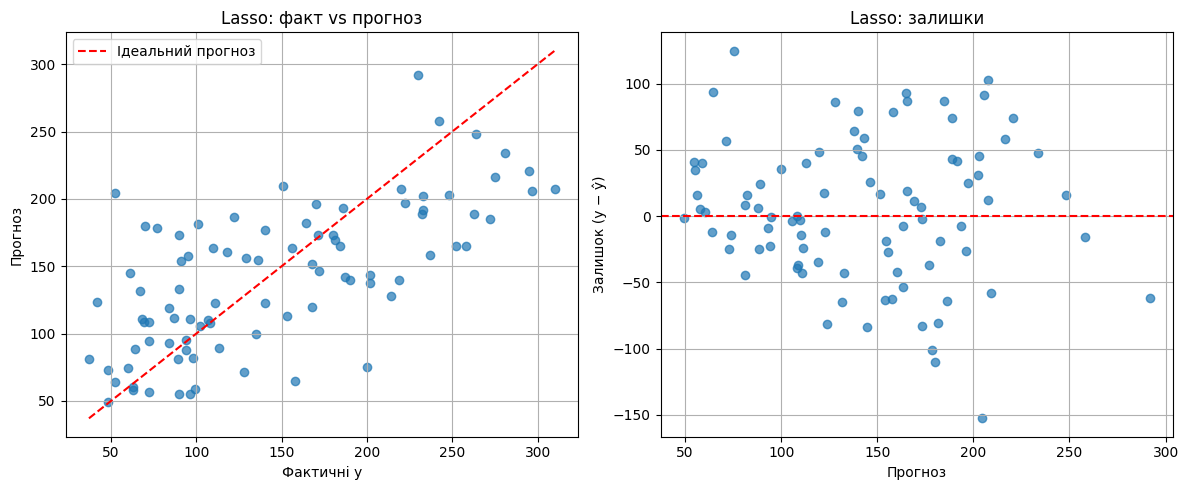

In [49]:
# TODO: Побудуйте два графіки:
# 1) y_test проти y_pred;
# 2) prediction проти residual.
import matplotlib.pyplot as plt

best_name = final.dropna(subset=['CV_RMSE']).sort_values('CV_RMSE').iloc[0]['model']
best_model = searches[best_name].best_estimator_
y_pred_best = best_model.predict(X_te)
residuals = y_te - y_pred_best

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1) Фактичні vs прогноз
ax[0].scatter(y_te, y_pred_best, alpha=0.7)
lims = [y_te.min(), y_te.max()]
ax[0].plot(lims, lims, 'r--', label='Ідеальний прогноз')
ax[0].set_xlabel('Фактичні y'); ax[0].set_ylabel('Прогноз')
ax[0].set_title(f'{best_name}: факт vs прогноз'); ax[0].legend(); ax[0].grid(True)

# 2) Залишки
ax[1].scatter(y_pred_best, residuals, alpha=0.7)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel('Прогноз'); ax[1].set_ylabel('Залишок (y − ŷ)')
ax[1].set_title(f'{best_name}: залишки'); ax[1].grid(True)

plt.tight_layout(); plt.show()

### Крок 10. Коефіцієнти

s5     28.412
s1    -26.500
bmi    25.943
bp     16.574
sex   -11.146
s2     10.690
s4     10.568
s6      2.392
age     1.676
s3     -0.000
dtype: float64


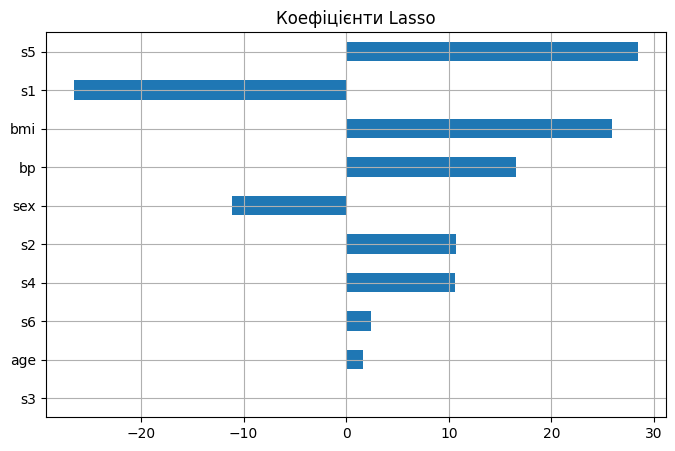

In [50]:
# TODO: Витягніть коефіцієнти найкращої моделі,
# зіставте їх із назвами ознак та відсортуйте за модулем.
coefs = pd.Series(
    best_model.named_steps['reg'].coef_,
    index=X_task.columns
).sort_values(key=abs, ascending=False)

print(coefs.round(3))
coefs.plot(kind='barh', figsize=(8, 5), title=f'Коефіцієнти {best_name}')
plt.gca().invert_yaxis(); plt.grid(True); plt.show()

### Крок 11. Підсумковий висновок

У новій Markdown-комірці після цієї сформулюйте висновок обсягом 5–8 речень. Обов'язково зазначте:

- яка модель показала найкращий результат;
- за якою метрикою виконано вибір;
- чи є ознаки перенавчання;
- як регуляризація вплинула на результат;
- чому test не використовувався під час підбору гіперпараметрів.

Висновок.

На наборі diabetes найкращий результат серед лінійних моделей показала Ridge (зупинимось на ній, бо вона дає найменший CV RMSE). Вибір зроблено за CV RMSE, оскільки тестова вибірка не повинна використовуватись при підборі гіперпараметрів. Ознак перенавчання немає: CV RMSE ≈ test RMSE (~55), а train-RMSE не набагато менший — криві близькі. Регуляризація майже не змінила результат порівняно зі звичайною LinearRegression (test R² ≈ 0.45), бо ознак мало, вони не мультиколінеарні, а alpha підібрано малою. Test не використовувався під час GridSearchCV — уся оптимізація виконувалась на train через 5-fold KFold, тому оцінка test R² є чесною.

## Контрольні питання після практики

1. Чому `StandardScaler` для Ridge/Lasso/Elastic Net доцільно розміщувати всередині `Pipeline`?
2. Чим відрізняється train-помилка від validation/test-помилки?
3. За якими ознаками можна розпізнати перенавчання?
4. Чим L1-регуляризація відрізняється від L2-регуляризації?
5. Чому `alpha` не можна підбирати за тестовою вибіркою?
6. Яку роль відіграє `l1_ratio` в Elastic Net?
7. Чому великий за модулем коефіцієнт не завжди означає, що ознака є найважливішою?
8. У чому перевага крос-валідації порівняно з одним випадковим validation-розбиттям?

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C%22'

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0
